# Memórias em workflows

AS memórias são importantes para o caso de agentes, uma vez que não precisamos passar toda vez um contexto gigante para a llm para ela não perder o contexto.


Temos 2 tipos de memórias.

1 - Short term memory: Memória de curto prazo

2 - Long term memory: Memória de longo prazo

## Short Term Memory

A memória de curto prazo é a memória conversacional, onde o próprio estado do workflow pode lidar. E como fazer isso? com os checkpointers, que persiste o passo a passo de cada interação do usuário com o workflow.

Podemos usar algumas técnicas para conseguirmos manusear as memórias de curto prazo.

- Trim Messages

- Deletar mensagens

- Resumir as mensagens

### Trim Messages

In [1]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [2]:
from langchain.chat_models import init_chat_model
from langchain_core.messages.utils import trim_messages, count_tokens_approximately


def call_model(state: MessagesState) -> MessagesState:
    model = init_chat_model(model="groq:openai/gpt-oss-120b", temperature=0)
    messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=384,
        start_on="human",
        end_on=(
            "human",
            "tool"
        )
    )
    response_model = model.invoke(messages)
    return {
        "messages": [response_model]
    }


In [3]:
from langgraph.graph import START, END
graph_builder.add_node("chatbot", call_model)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [4]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph_compiled = graph_builder.compile(checkpointer=checkpointer)

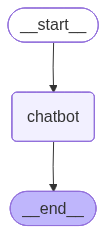

In [5]:
from IPython.display import display, Image

display(Image(graph_compiled.get_graph().draw_mermaid_png()))

In [ ]:
import gradio as gr

config = {
    "configurable": {
        "thread_id": "ramonzinho"
    }
}

# Criando função apenas para rodar no gradio

def chat(user_input: str, history):
    result = graph_compiled.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": user_input
                }
            ]
        },
        config=config
    )

    print(result)
    print(f'TOTAL TOKENS: {result["messages"][-1].response_metadata["token_usage"]["total_tokens"]}')
    return result["messages"][-1].content

gr.ChatInterface(fn=chat, type="messages").launch()



* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='Olá', additional_kwargs={}, response_metadata={}, id='d5952cdb-77fb-4bd8-95a5-aed86d7e98f7'), AIMessage(content='Olá! Como posso ajudar você hoje?', additional_kwargs={'reasoning_content': 'The user says "Olá" (Portuguese for "Hello"). We should respond in Portuguese, greeting back. Keep it friendly.'}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 72, 'total_tokens': 116, 'completion_time': 0.097900057, 'prompt_time': 0.002807926, 'queue_time': 0.148431041, 'total_time': 0.100707983}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8c2cca97f9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--adcc7106-aef2-47c4-acc7-5833cbeb9922-0', usage_metadata={'input_tokens': 72, 'output_tokens': 44, 'total_tokens': 116}), HumanMessage(content='Meu nome é ramon, e o seu?', additional_kwargs={}, response_metadata={}, id='5bdc694f-c358-40ed-9c87-fec81edfa31

# Resumir conversa

### Criando classes de estado

Uma para o estado global (State) e outra para o nó de resumo (LLMInputState)

In [13]:
from langgraph.graph.message import MessagesState, AnyMessage
from typing import TypedDict
from langmem.short_term import RunningSummary

class State(MessagesState):
    context: dict[str, RunningSummary]  

class LLMInputState(TypedDict):  
    summarized_messages: list[AnyMessage]
    context: dict[str, RunningSummary]

### Criando o nó de resumo

In [23]:
from langchain.chat_models import init_chat_model

model_summary = init_chat_model(model="groq:meta-llama/llama-4-scout-17b-16e-instruct", temperature=0, max_tokens=500)
model = init_chat_model(model="groq:openai/gpt-oss-120b", temperature=0, max_tokens=8000)

In [24]:
from langmem.short_term import SummarizationNode

summarization_node = SummarizationNode(  
    token_counter=count_tokens_approximately,
    model=model_summary,
    max_tokens=256,
    max_tokens_before_summary=256,
    max_summary_tokens=128,
)

In [25]:
def call_model(state: LLMInputState):  
    response = model.invoke(state["summarized_messages"])
    return {"messages": [response]}

### Criando estrutura do grafo

In [26]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import START, END

builder = StateGraph(State)
builder.add_node("call_model", call_model)
builder.add_node("summarize", summarization_node)  

builder.add_edge(START, "summarize")
builder.add_edge("summarize", "call_model")
builder.add_edge("call_model", END)


checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

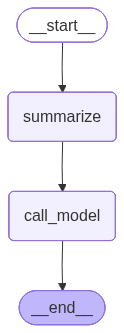

In [27]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

### Rodando grafo

In [ ]:
import gradio as gr

config = {
    "configurable": {
        "thread_id": "ramonzinho2"
    }
}

# Criando função apenas para rodar no gradio

def chat(user_input: str, history):
    result = graph.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": user_input
                }
            ]
        },
        config=config
    )

    print(result)
    print(f'TOTAL TOKENS: {result["messages"][-1].response_metadata["token_usage"]["total_tokens"]}')
    return result["messages"][-1].content

gr.ChatInterface(fn=chat, type="messages").launch()

{'messages': [HumanMessage(content='Olá, meu nome é ramon tudo certo?', additional_kwargs={}, response_metadata={}, id='9187373c-a101-4beb-9e16-2f6879de2ff3'), AIMessage(content='Olá, Ramon! Tudo certo por aqui. Como posso ajudar você hoje?', additional_kwargs={'reasoning_content': 'The user greets in Portuguese: "Olá, meu nome é ramon tudo certo?" Means "Hello, my name is Ramon, everything alright?" The assistant should respond politely, maybe in Portuguese, acknowledging. No disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 81, 'total_tokens': 157, 'completion_time': 0.170414551, 'prompt_time': 0.018590389, 'queue_time': 0.246732972, 'total_time': 0.18900494}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_b0f0a60553', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--950370c3-70bf-448e-b451-b4d1e64d5bd5-0', usage_metadata={'input_tokens'

{'messages': [HumanMessage(content='Olá, meu nome é ramon tudo certo?', additional_kwargs={}, response_metadata={}, id='9187373c-a101-4beb-9e16-2f6879de2ff3'), AIMessage(content='Olá, Ramon! Tudo certo por aqui. Como posso ajudar você hoje?', additional_kwargs={'reasoning_content': 'The user greets in Portuguese: "Olá, meu nome é ramon tudo certo?" Means "Hello, my name is Ramon, everything alright?" The assistant should respond politely, maybe in Portuguese, acknowledging. No disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 81, 'total_tokens': 157, 'completion_time': 0.170414551, 'prompt_time': 0.018590389, 'queue_time': 0.246732972, 'total_time': 0.18900494}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_b0f0a60553', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--950370c3-70bf-448e-b451-b4d1e64d5bd5-0', usage_metadata={'input_tokens'

In [32]:
from pprint import pprint

snapshot = graph.get_state(config)
pprint(snapshot.values)

{'context': {'running_summary': RunningSummary(summary='## Resumo da Conversa '
                                                       'sobre Potenciais '
                                                       'Ultrasoft (USPP) em '
                                                       'Química Quântica\n'
                                                       '\n'
                                                       '### Introdução\n'
                                                       '- **Ramon** perguntou '
                                                       'sobre **potenciais '
                                                       'ultrasoft (USPP)** em '
                                                       'química quântica.\n'
                                                       '- **USPP** são '
                                                       'pseudopotenciais que '
                                                       'permitem cálculos mais '
          